# SEM Microstructure Classification with Spatial Holdout

## Objective

This notebook examines whether local SEM texture can distinguish three microstructure classes.

The available dataset contains one parent image per class. This is sufficient for a patch-level proof of concept, but not for estimating performance on unseen specimens. To reduce the leakage associated with a random patch split, training and test patches are taken from spatially separated regions of each parent image.

The reported test scores therefore measure transfer across image regions, not generalization to new samples.

## 1. Setup

In [1]:
from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import sklearn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"TensorFlow: {tf.__version__}")

I0000 00:00:1789383521.452002 2551185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789383521.515337 2551185 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python: 3.10.21
NumPy: 2.2.6
scikit-learn: 1.7.2
TensorFlow: 2.21.0


I0000 00:00:1789383522.985477 2551185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Image paths

In [2]:
def find_repo_root():
    cwd = Path.cwd()
    if (cwd / "notebooks").exists():
        return cwd
    if cwd.name == "notebooks":
        return cwd.parent
    return cwd

REPO_ROOT = find_repo_root()
IMAGE_DIR = REPO_ROOT / "data" / "sem"

image_paths = {
    0: IMAGE_DIR / "class1.jpg",
    1: IMAGE_DIR / "class2.jpg",
    2: IMAGE_DIR / "class3.jpg",
}

for label, path in image_paths.items():
    print(f"class {label}: {path} | exists={path.exists()}")

class 0: /smb/twallis/m/data/sem/class1.jpg | exists=True
class 1: /smb/twallis/m/data/sem/class2.jpg | exists=True
class 2: /smb/twallis/m/data/sem/class3.jpg | exists=True


The image files are treated as local input data. If redistribution rights are unclear, keep the files out of the public repository and document how authorized users can provide them locally.

## 3. Load and inspect the images

In [3]:
def load_grayscale(path):
    image = Image.open(path).convert("L")
    return np.asarray(image, dtype=np.float32) / 255.0

images = {
    label: load_grayscale(path)
    for label, path in image_paths.items()
}

for label, image in images.items():
    print(
        f"class {label}: shape={image.shape}, "
        f"min={image.min():.3f}, max={image.max():.3f}, "
        f"mean={image.mean():.3f}"
    )

class 0: shape=(959, 1280), min=0.000, max=1.000, mean=0.538
class 1: shape=(959, 1280), min=0.000, max=1.000, mean=0.518
class 2: shape=(959, 1280), min=0.000, max=1.000, mean=0.514


The classes show visibly different texture and feature density. The analysis below tests whether those local differences can be learned from small image patches.

## 4. Spatial train/test partition

A random split of patches from the same image can place nearly identical local texture in both training and test sets. Here each image is divided spatially: the left portion supplies training/validation patches and the right portion is reserved for testing.

This is stricter than a random patch split, but both regions still originate from the same parent image.

In [4]:
TRAIN_FRACTION = 0.70

spatial_regions = {}

for label, image in images.items():
    split_col = int(image.shape[1] * TRAIN_FRACTION)

    spatial_regions[label] = {
        "train": image[:, :split_col],
        "test": image[:, split_col:],
    }

    print(
        f"class {label}: "
        f"train region={spatial_regions[label]['train'].shape}, "
        f"test region={spatial_regions[label]['test'].shape}"
    )

class 0: train region=(959, 896), test region=(959, 384)
class 1: train region=(959, 896), test region=(959, 384)
class 2: train region=(959, 896), test region=(959, 384)


## 5. Extract non-overlapping patches

In [5]:
PATCH_SIZE = 32
STRIDE = 32

def extract_patches(image, patch_size=32, stride=32):
    patches = []
    height, width = image.shape

    for row in range(0, height - patch_size + 1, stride):
        for col in range(0, width - patch_size + 1, stride):
            patch = image[
                row:row + patch_size,
                col:col + patch_size,
            ]
            patches.append(patch)

    return np.asarray(patches, dtype=np.float32)

X_train_parts = []
y_train_parts = []
X_test_parts = []
y_test_parts = []

for label in sorted(spatial_regions):
    train_patches = extract_patches(
        spatial_regions[label]["train"],
        patch_size=PATCH_SIZE,
        stride=STRIDE,
    )
    test_patches = extract_patches(
        spatial_regions[label]["test"],
        patch_size=PATCH_SIZE,
        stride=STRIDE,
    )

    X_train_parts.append(train_patches)
    y_train_parts.append(np.full(len(train_patches), label))

    X_test_parts.append(test_patches)
    y_test_parts.append(np.full(len(test_patches), label))

X_train_full = np.concatenate(X_train_parts, axis=0)
y_train_full = np.concatenate(y_train_parts, axis=0)

X_test = np.concatenate(X_test_parts, axis=0)
y_test = np.concatenate(y_test_parts, axis=0)

print(f"Training-region patches: {len(X_train_full)}")
print(f"Held-out-region patches: {len(X_test)}")

Training-region patches: 2436
Held-out-region patches: 1044


In [6]:
train_counts = pd.Series(y_train_full).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

patch_counts = pd.DataFrame({
    "training_region": train_counts,
    "held_out_region": test_counts,
})

display(patch_counts)

,training_region,held_out_region
0,812,348
1,812,348
2,812,348


## 6. Training and validation sets

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (1948, 32, 32, 1)
X_val:   (488, 32, 32, 1)
X_test:  (1044, 32, 32, 1)


## 7. Convolutional neural network

In [8]:
def build_cnn(input_shape=(PATCH_SIZE, PATCH_SIZE, 1), n_classes=3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.25),
        layers.Dense(n_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

model = build_cnn()
model.summary()

E0000 00:00:1789383537.347410 2551185 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789383537.348218 2551267 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789383537.432452 2551185 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,475 (99.51 KB)

 Trainable params: 25,475 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the model

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6227 - loss: 0.8676 - val_accuracy: 0.8852 - val_loss: 0.5228
Epoch 2/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8342 - loss: 0.4358 - val_accuracy: 0.9139 - val_loss: 0.2727
Epoch 3/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9251 - loss: 0.2515 - val_accuracy: 0.9795 - val_loss: 0.1327
Epoch 4/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9564 - loss: 0.1496 - val_accuracy: 0.9816 - val_loss: 0.0885
Epoch 5/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9671 - loss: 0.1103 - val_accuracy: 0.9775 - val_loss: 0.0636
Epoch 6/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9774 - loss: 0.0840 - val_accuracy: 0.9795 - val_loss: 0.0578
Epoch 7/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9779 - loss: 0.0756 - val_accuracy: 0.9857 - val_loss: 0.0487
Epoch 8/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9805 - loss: 0.0765 - val_accuracy: 0.9611 - val_loss

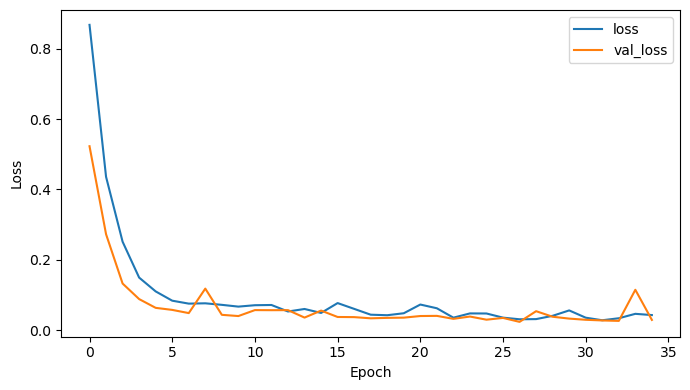

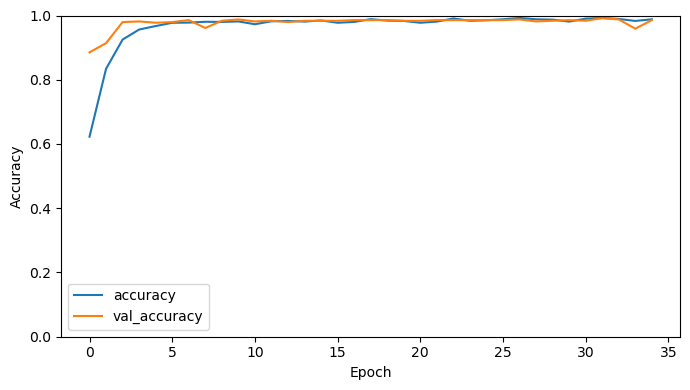

In [10]:
history_df = pd.DataFrame(history.history)

ax = history_df[["loss", "val_loss"]].plot(figsize=(7, 4))
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.show()

ax = history_df[["accuracy", "val_accuracy"]].plot(figsize=(7, 4))
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Evaluate on the spatially held-out regions

In [11]:
test_prob = model.predict(X_test, verbose=0)
test_pred = np.argmax(test_prob, axis=1)

test_accuracy = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")

print(f"Spatial-holdout accuracy: {test_accuracy:.3f}")
print(f"Spatial-holdout macro F1: {test_f1:.3f}")
print()
print(classification_report(y_test, test_pred, digits=3))

Spatial-holdout accuracy: 0.946
Spatial-holdout macro F1: 0.946

              precision    recall  f1-score   support

           0      1.000     1.000     1.000       348
           1      0.869     0.989     0.925       348
           2      0.987     0.851     0.914       348

    accuracy                          0.946      1044
   macro avg      0.952     0.946     0.946      1044
weighted avg      0.952     0.946     0.946      1044



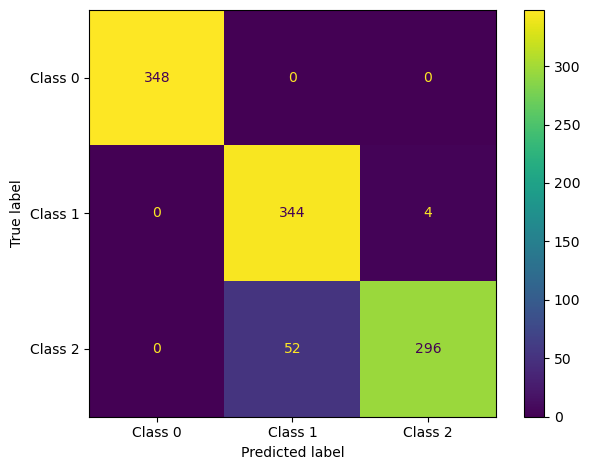

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["Class 0", "Class 1", "Class 2"],
)

plt.tight_layout()
plt.show()

## 10. Class-wise confidence

In [13]:
confidence_rows = []

for class_id in sorted(np.unique(y_test)):
    mask = y_test == class_id
    true_class_probability = test_prob[mask, class_id]

    confidence_rows.append({
        "class": class_id,
        "n_patches": mask.sum(),
        "mean_true_class_probability": true_class_probability.mean(),
        "median_true_class_probability": np.median(true_class_probability),
    })

confidence_df = pd.DataFrame(confidence_rows)
display(confidence_df.round(3))

,class,n_patches,mean_true_class_probability,median_true_class_probability
0,0,348,0.998,1.0
1,1,348,0.981,1.0
2,2,348,0.863,1.0


## 11. Optional random-patch comparison

The following comparison is included only to illustrate how validation design can affect apparent performance. A random patch split allows patches from the same parent image to appear in both training and test sets, so its score should not be interpreted as independent generalization.

In [14]:
all_patches = []
all_labels = []

for label, image in images.items():
    patches = extract_patches(
        image,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
    )
    all_patches.append(patches)
    all_labels.append(np.full(len(patches), label))

X_all = np.concatenate(all_patches, axis=0)[..., np.newaxis]
y_all = np.concatenate(all_labels, axis=0)

X_random_train, X_random_test, y_random_train, y_random_test = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

random_model = build_cnn()

random_model.fit(
    X_random_train,
    y_random_train,
    validation_split=0.20,
    epochs=60,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

random_pred = np.argmax(
    random_model.predict(X_random_test, verbose=0),
    axis=1,
)

random_accuracy = accuracy_score(y_random_test, random_pred)
random_f1 = f1_score(y_random_test, random_pred, average="macro")

comparison = pd.DataFrame({
    "validation": [
        "Random patch split",
        "Spatial holdout",
    ],
    "accuracy": [
        random_accuracy,
        test_accuracy,
    ],
    "macro_f1": [
        random_f1,
        test_f1,
    ],
})

display(comparison.round(3))

,validation,accuracy,macro_f1
0,Random patch split,0.973,0.973
1,Spatial holdout,0.946,0.946


The random patch split reaches a macro F1 score of 0.973, compared with 0.946 for the spatial holdout. The reduction indicates that random patch splitting gives a somewhat more optimistic estimate when patches from the same parent image are distributed across training and test sets.
The spatial holdout remains strong, showing that the learned texture differences persist across separated regions of the images. However, both tests use regions derived from the same three parent images and therefore do not measure generalization to independent specimens.

## 12. Patch-size sensitivity

Patch size controls the spatial context available to the classifier. Very small patches may omit relevant morphology, while larger patches provide more context at the cost of fewer independent training examples.

The main analysis uses 32 × 32 pixel patches. A systematic patch-size comparison is most useful once additional independent images are available, because performance differences measured within the same three parent images can still reflect image-specific texture.

## 13. Summary

A convolutional neural network was used to distinguish local texture patterns in three SEM images. With spatially separated training and test regions, the model reached an accuracy and macro F1 score of 0.946.
A conventional random patch split produced a higher macro F1 score of 0.973. The difference illustrates the sensitivity of image-classification performance to the validation strategy.
The present dataset contains one parent image per class. The results therefore demonstrate discrimination of local texture within these images, not classification of unseen specimens. Evaluation at the specimen level would require multiple independent images or samples per class, with the train-test split performed at the parent-image or specimen level.